# Bottlenecks

Notebook centrado en envejecimiento, estancamiento, dependencias y riesgo operativo.

Este cuaderno usa los artefactos ya calculados desde `src.pipeline`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline import run_baseline_pipeline

PATH_XLSX = project_root / "data" / "raw" / "DatosBusquedaAvanzada20250208.xlsx"

artifacts = run_baseline_pipeline(
    workbook_path=PATH_XLSX,
    rate_window_days=60,
    dashboard_horizon_days=5,
    scenario_horizons=(5, 10, 20),
)

bottleneck_thresholds = artifacts["bottleneck_thresholds"]
task_alerts = artifacts["task_alerts"]
owner_bottlenecks = artifacts["owner_bottlenecks"]
column_bottlenecks = artifacts["column_bottlenecks"]
type_bottlenecks = artifacts["type_bottlenecks"]


In [2]:
display(bottleneck_thresholds)
display(task_alerts.head(20))


,metric,value
0,open_age_p75,259.03
1,open_age_p90,317.45
2,stagnation_p75,242.00
3,stagnation_p90,243.00
4,history_absolute_threshold_days,60.00
5,complexity_threshold,3.00


,Card ID,Owner,Column Name,task_status,Type Name,age_days,days_since_last_moved,subtasks_count,has_any_links,owner_forecast_wip,...,owner_forecast_status_reason,benchmark_source,benchmark_median_days,benchmark_p90_days,age_vs_benchmark,blocked_state,block_time_hours,alert_score,alert_level,alert_reason
0,5449,Otros 2,Backlog,open,PROYECTO INTERNO,306.49,243.0,5.0,1,3.92,...,projected backlog exceeds horizon,owner_type,30.98,104.24,9.89,yes,6479.90,11,bottleneck,old_open; stagnant; older_than_history; depend...
1,4480,Otros 2,Backlog,open,PROYECTO INTERNO,331.51,243.0,6.0,1,3.92,...,projected backlog exceeds horizon,owner_type,30.98,104.24,10.70,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
2,4807,Consultor 1,En progreso,in_progress,PROYECTO INTERNO,326.33,243.0,3.0,1,7.75,...,projected backlog exceeds horizon,owner_type,132.52,192.50,2.46,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
3,4876,Consultor 6,En progreso,in_progress,PROYECTO EXTERNO,324.47,277.0,0.0,0,1.75,...,projected backlog exceeds horizon,owner_type,18.19,189.59,17.84,yes,2303.93,8,bottleneck,old_open; stagnant; older_than_history; curren...
4,6360,Consultor 4,Backlog,open,PRODUCTO,270.70,243.0,3.0,1,5.33,...,projected backlog exceeds horizon,owner_type,34.53,85.98,7.84,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
5,5108,Técnico 8,En progreso,in_progress,PROYECTO EXTERNO,317.71,115.0,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,147.52,yes,2763.35,6,bottleneck,old_open; older_than_history; currently_blocke...
6,5191,Consultor 4,En progreso,in_progress,PROYECTO EXTERNO,317.27,118.0,0.0,0,5.33,...,projected backlog exceeds horizon,owner_type,21.83,98.73,14.53,yes,2564.17,6,bottleneck,old_open; older_than_history; currently_blocke...
7,5810,Consultor 2,Backlog,open,PROYECTO INTERNO,299.45,242.0,0.0,1,3.08,...,open work but no recent completions,type,4.01,14.78,74.72,no,0.00,6,bottleneck,stagnant; older_than_history; dependency_risk;...
8,5809,Consultor 2,Backlog,open,PROYECTO INTERNO,299.45,242.0,0.0,1,3.08,...,open work but no recent completions,type,4.01,14.78,74.72,no,0.00,6,bottleneck,stagnant; older_than_history; dependency_risk;...
9,7140,Técnico 7,Backlog,open,PRODUCTO,247.36,131.0,0.0,1,3.75,...,projected backlog exceeds horizon,owner_type,13.07,48.37,18.93,no,2662.69,6,bottleneck,old_open; older_than_history; dependency_risk;...


In [3]:
display(owner_bottlenecks)
display(column_bottlenecks)
display(type_bottlenecks)


,Owner,open_tasks,risk_tasks,bottleneck_tasks,old_open_tasks,stagnant_tasks,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,historical_block_tasks,median_open_age_days,max_open_age_days,dominant_column,dominant_column_tasks,forecast_wip,forecast_status,forecast_status_reason,bottleneck_score,bottleneck_status
0,Consultor 4,6,2,4,3,2,1,1,2,2,253.70,317.27,En progreso,3,5.33,risk,projected backlog exceeds horizon,14,bottleneck
1,Técnico 8,5,1,4,1,0,0,0,4,4,100.45,317.71,En progreso,2,4.67,risk,projected backlog exceeds horizon,14,bottleneck
2,Técnico 7,4,1,3,3,0,3,0,0,4,247.35,247.36,Backlog,4,3.75,risk,projected backlog exceeds horizon,11,bottleneck
3,Consultor 1,8,2,2,1,2,1,1,1,1,112.48,326.33,En progreso,7,7.75,risk,projected backlog exceeds horizon,9,bottleneck
4,Otros 2,4,0,2,2,2,2,2,1,1,194.47,331.51,Backlog,2,3.92,risk,projected backlog exceeds horizon,8,bottleneck
5,Consultor 2,3,0,2,0,2,2,0,0,0,299.45,299.45,Backlog,2,3.08,no_throughput,open work but no recent completions,7,bottleneck
6,Consultor 6,2,1,1,1,1,0,0,1,1,217.49,324.47,En progreso,2,1.75,risk,projected backlog exceeds horizon,5,bottleneck
7,Técnico 1,1,0,1,0,0,0,0,1,1,233.61,233.61,Backlog,1,0.75,risk,projected backlog exceeds horizon,4,bottleneck
8,Comercial 2,1,1,0,0,0,0,0,0,0,67.70,67.70,Testeos internos,1,1.0,no_throughput,open work but no recent completions,2,bottleneck
9,Técnico 5,1,0,1,1,1,0,1,0,0,318.54,318.54,Backlog,1,0.58,healthy,capacity aligned with horizon,2,bottleneck


,column_name,open_tasks,risk_tasks,bottleneck_tasks,owners_involved,median_age_days,max_age_days,mean_days_since_last_moved,dependency_risk_tasks,currently_blocked_tasks,historical_block_tasks,bottleneck_status
0,Backlog,18,4,10,11,240.48,331.51,151.53,8,2,6,bottleneck
1,En progreso,19,6,7,7,122.48,326.33,158.00,1,5,5,bottleneck
2,Testeos internos,6,5,1,3,79.64,82.64,70.33,0,1,1,bottleneck
3,Pilotos / Batería de pruebas,3,2,1,3,100.45,193.50,44.00,0,1,1,bottleneck
4,A empezar,1,0,1,1,193.50,193.50,157.00,0,1,1,bottleneck


,type_name,open_tasks,risk_tasks,bottleneck_tasks,median_age_days,max_age_days,median_days_since_last_moved,mean_age_vs_benchmark,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,type_open_age_p75,type_open_age_p90,bottleneck_status
0,PROYECTO INTERNO,16,3,8,212.52,331.51,242.0,37.44,5,4,3,301.21,322.44,bottleneck
1,PROYECTO EXTERNO,15,6,8,155.67,324.47,116.5,38.46,0,0,7,263.60,317.54,bottleneck
2,PRODUCTO,16,8,4,84.70,270.70,79.0,8.55,4,1,0,139.43,247.36,bottleneck


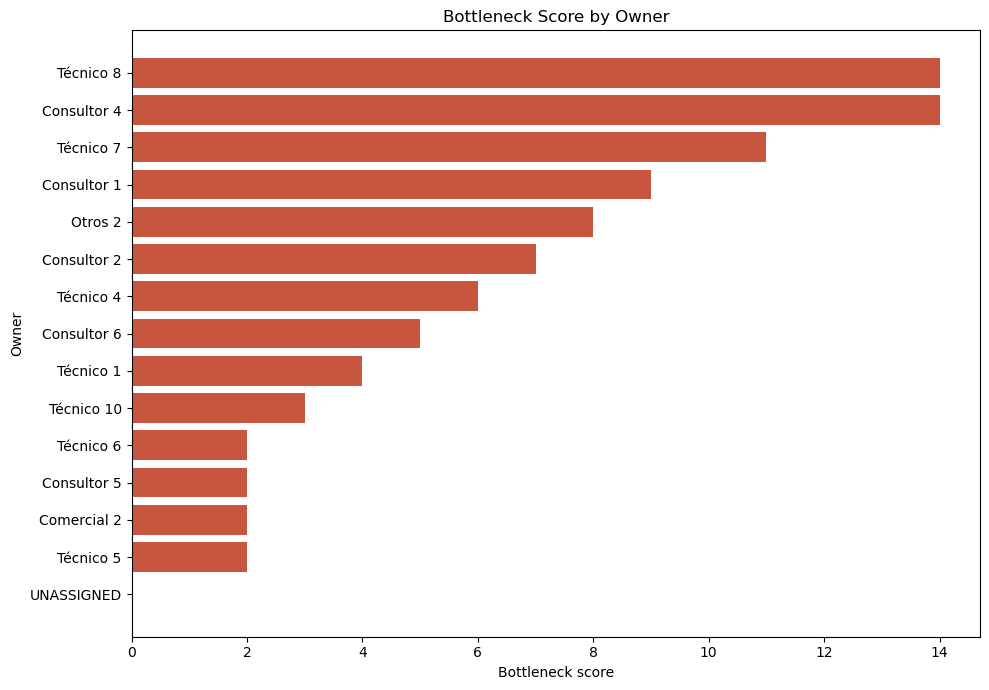

In [4]:
owner_plot = owner_bottlenecks.sort_values("bottleneck_score", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(owner_plot["Owner"], owner_plot["bottleneck_score"], color="#C8553D")
plt.title("Bottleneck Score by Owner")
plt.xlabel("Bottleneck score")
plt.ylabel("Owner")
plt.tight_layout()
plt.show()


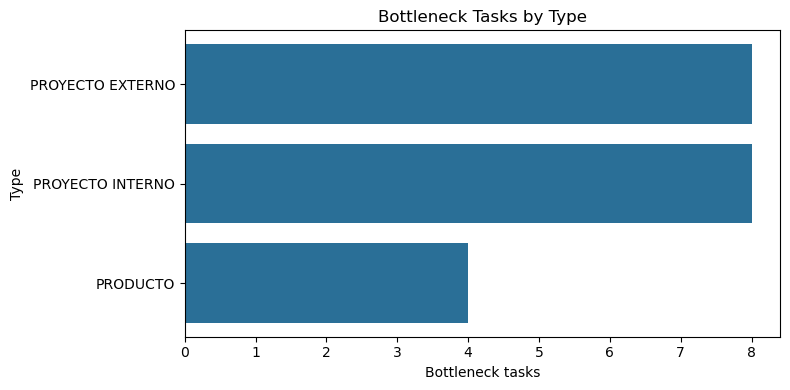

In [5]:
type_plot = type_bottlenecks.sort_values("bottleneck_tasks", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(type_plot["type_name"], type_plot["bottleneck_tasks"], color="#2A6F97")
plt.title("Bottleneck Tasks by Type")
plt.xlabel("Bottleneck tasks")
plt.ylabel("Type")
plt.tight_layout()
plt.show()
